# Aula Lab. 3 - OpenCV
## Transformações Espaciais/Geométricas
Nestes exercícios vamos entnder os conceitos de:
* Coordenadas e Transformação Reversa
    * f(x, y) = T(u,v)
* Métodos de Interpolação
    * exemplos: vizinho mais próximo (nearest neighbor) e bilinear
* Transformações afins e suas matrizes
    * Translado (translate)
    * Escala (scale)
    * Rotação (rotation)
    * Cisalhamento (shear)

Começamos com o cabeçalho padrão:

In [2]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

cv.samples.addSamplesDataSearchPath("./data")

## 1. Coordenadas
O sistema de coordenadas das imagens é um sistema cartesiano, centrado no topo esquerdo da imagem:

![Coordenadas da Imagem](https://documentation.euresys.com/Products/OPEN_EVISION/OPEN_EVISION_2_16/en-us/Content/Resources/Images/03-1-2_Manipulating/Image_Coordinate_Systems_integer.png)

As transformações geométricas não alteram o valor dos pixels, apenas mudam sua posição. Isso quer dizer que um pixel que se encontrava numa posição (X<sub>1</sub>, Y<sub>1</sub>), após uma transformação irá ser relocado para uma nova posição (X', Y')

![Exemplo Translação](https://www.math.net/img/a/geometry/transformation/translation/coordinate-rectangle.png)

### Transformação reversa e coordenadas

O comum em operações matemáticas de transformação é a ordem reversa, ou seja, toma-se como ponto de partida o destino para descrever qual operação foi aplicada na origem para chegar no resultado atual. Isso também se aplica na computação, resultando em operações mais eficientes (melhor automatizada e menos variáveis intermediárias).

Para não confundir as coordenadas entre origem e destino, são adotados um novo conjunto de símbolos para a imagem de destino:
* x -> u
* y -> v
* z -> w

Uma transformação geométrica então é expressa de tal forma que: o valor de cada pixel P(u,v) na imagem de destino, será igual ao valor de um pixel da imagem fonte I(x,y) tal que x = T(u) e y = T(v)

#### Exercício Exemplo

1. Abra a imagem 'HappyFish.jpg.jpg' em modo RGB
1. Use a propriedade .shape da imagem aberta para ler as dimensões da imagem (_L_ para linhas, _C_ para colunas, _P_ para planos de cores)
1. Crie uma nova imagem (matriz Numpy de zeros) com as mesmas dimensões
1. Faça um loop _for_ aninhado para copiar os pixels da imagem de origem para a imagem de destino espelhado horizontalmente
    * coordenada vertical: y = v
    * coordenada horizontal: x = (C-1) - u
1. Imprima a imagem original e a copia invertida horizontalmente com Matplot

> É possivel automaziar a inversão com o slice-range de Python (operador [::-1]), mas esse exemplo-exercício é didatico e é para ser feito com for

## Resolução Exercício

194 259 3


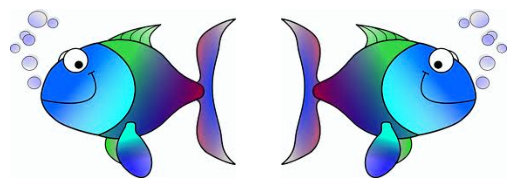

In [6]:
# complete o código
fish = cv.imread(cv.samples.findFile('data/data/HappyFish.jpg'), cv.IMREAD_COLOR)
L, C, P = fish.shape
print(L, C, P)
fish_mirrorh = np.zeros((L, C, P), dtype=np.uint8)
#fish_mirrorh[:,:,:] = fish[:,::-1,:]
for v in range(L):
    for u in range(C):
        x = (C - 1) - u
        y = v
        fish_mirrorh[v, u, :] = fish[y, x, :]
plt.subplot(1, 2, 1)
plt.axis('off')
plt.imshow(fish)
plt.subplot(1, 2, 2)
plt.axis('off')
plt.imshow(fish_mirrorh)
plt.show()

## 2. Translação
A [translação](https://medium.com/@henriquevedoveli/geometric-transformations-in-image-processing-150b0de27c7a) consiste em mover a imagem na horizontal (-&Delta;x, +&Delta;x) ou na vertical (-&Delta;y, +&Delta;y) uma quantidade de pixels.

>Note que estaremos usando valores inteiros de posição, que seria é o mesmo que usar valores fracionários com interpolação do vizinho mais próximo (arredonda o valor para inteiro).

![Exemplo Translação](https://www.math.net/img/a/geometry/transformation/translation/coordinate-rectangle.png)

Temos que para translado:

* $x=u-d_{x}$
* $y=v-d_{y}$

Outra forma de se definir uma transposição é através de uma matriz de afinidade: $\begin{vmatrix}x\\y\\1\end{vmatrix}=\begin{vmatrix}1&0&-d_{x}\\0&1&-d_{y}\\0&0&1\end{vmatrix}*\begin{vmatrix}u\\v\\1\end{vmatrix}$

OpenCV possui suporte para operações geométricas através de matriz de afinidade simplificada (omite a 3<sup>a</sup>linha): $\begin{vmatrix}1&0&-d_{x}\\0&1&-d_{y}\end{vmatrix}$.
Atravéz da função
```python
dst = cv.warpAffine(src, M, dsize[, flags[, borderMode[, borderValue]]])
```
* src: Imagem de origem
* M: mtraiz de transformação 2x3, pode ser np.float32
* dsize: tam. da imagem de destino: (largura, altura)
* flags (opcional): tipo de interpolação, ex.: cv.INTER_LINEAR (padrão) ou cv.INTER_NEAREST
* borderMode (opicioanl): regra quando uma coordenada cai fora da imagem de origem (extrapolação) ex.: cv.BORDER_CONSTANT
* borderValue (opicioanl): para borda constante, o valor da cor (0 como padrão)

> Perceba que ao multiplicar linha pela coluna, é obtida as duas equações anteriores. A forma de matriz de afinidade permite acumular operações geométricas.

### Exercícios

Ainda com a imagem do HappyFish.
1. Crie uma função que recebe como argumentos
    1. a imagem original
    1. o quanto se quer deslocar em pixels em x (_tx_) e em y (_ty_)
    1. crie uma matriz 2x3 de translado com np.float32([[1, 0, _tx_], [0, 1, _ty_]])
    1. retorne o resultado de warpAffine, usando _dsize_ com mesmo tamanho da imagem de entrada
1. Crie subplot 4x4 tal que
    1. a primeira imagem seja a original
    1. a segunda seja deslocado 25px para baixo
    1. a terceira imagem seja deslocada 50px para esquerda
    1. a quarda imagem seja deslocada 30px para cima e 75px pra a direira

In [ ]:
def transpose(img, tx, ty):
    ?
?

Repita o exercício anterior, criando uma nova função, mas duplique o tamanho da imagem de destino (mostre os eixos).
Utilze antes de plt.show():
```python
# mude os valores para seu gosto
plt.subplots_adjust(wspace=.5) # para ajustar o espaço entre imagens
plt.gcf().set_dpi(200.0) # para aumentar as imagens se ficarem muito pequenas
```

In [ ]:
def transpose2(img, tx, ty):
    ?
?

Repita o exercício anterior, criando uma nova função, duplicando a área de destino e utilize repetição de borda (BORDER_REPLICATE)

In [ ]:
def transpose3(img, tx, ty):
    ?
?

## 3. Escala
A [escala](https://medium.com/@ckekula/spatial-transformations-in-digital-image-processing-54d40d927147) consiste em aumentar ou diminuir uma imagem na horizontal (S<sub>x</sub>) ou na vertical (S<sub>y</sub>) uma quantidade de pixels.

> Note que usar valores especiais como 1/2, 1/4 resulta em uma operações muito mais rápida, pois estaremos apenas eliminando ou duplicando colunas e linhas como já fizemos anteriormente. Similarmente o mesmo acontece para inteiros multiplos de 2 como 2x, 4x. [interpolação de vizinhos próximos]

![Exemplo Escala](https://miro.medium.com/v2/resize:fit:4800/format:webp/1*0yB5egpG22Wi5vkFUtB9yg.png)

Temos que para translado:

* $x=uS_{x}$
* $y=vS_{y}$

Outra forma de se definir uma transposição é através de uma matriz de afinidade: $\begin{vmatrix}x\\y\\1\end{vmatrix}=\begin{vmatrix}S_{x}&0&0\\0&S_{y}&0\\0&0&1\end{vmatrix}*\begin{vmatrix}u\\v\\1\end{vmatrix}$

OpenCV possui suporte para operações geométricas através de matriz de afinidade simplificada (omite a 3<sup>a</sup>linha): $\begin{vmatrix}S_{x}&0&0\\0&S_{y}&0\end{vmatrix}$.

**Obs.:** quando S<sub>x</sub>=S<sub>y</sub> falamos que a escala é 

### Exercícios

Ainda com a imagem do HappyFish.
1. Crie uma função que recebe como argumentos
    1. a imagem original
    1. o valor de escala em x (_sx_) e em y (_sy_)
        * faça a escala em y ser igual à escalça em x quando o argumento _sy_ for omitido
    1. crie uma matriz 2x3 de escala com np.float32([[_sx_, 0, 0], [0, _sy_, 0]])
    1. retorne o resultado de warpAffine, usando _dsize_ com mesmo tamanho da imagem de entrada
1. Crie subplot 4x4 tal que
    1. a primeira imagem seja a original
    1. a segunda seja 25% menor uniforme
    1. a terceira seja o dobro, apenas em y
    1. a quarda seja 10% maior em x e 20% menor em y

In [ ]:
def scale(img, sx, sy=0):
    ?
?

Repita o exercício anterior, criando uma nova função, mas duplique o tamanho da imagem de destino (mostre os eixos).
Utilze antes de plt.show():
```python
# mude os valores para seu gosto
plt.subplots_adjust(wspace=.5) # para ajustar o espaço entre imagens
plt.gcf().set_dpi(200.0) # para aumentar as imagens se ficarem muito pequenas
```

In [ ]:
def scale(img, sx, sy=0):
    ?
?

### Exercício desafio

Faça uma função tal que:
1. A área de desenho de destino seja o dobro da área da imagem de entrsda
1. A função deve receber como argumentos escala e translado
    * adicione a terceira lina nas matrizes de tranposição e escala
        * [[...], [...], [0, 0, 1]]
    * multiplique as matrizes com np.matmul(mat1, mat2) ou mat1 @ mat2
    * imprima a matriz resultante (perceba que ela é a combinação das duas matrizes)
        * [[sx, 0, tx], [0, sy, ty], [0,0,1]]
    * remova a terceira linha antes de usar em warpAffine
        * mtx = np.delete(mtx, 2, axis=0)
1. A função deve retornar o resultado de warpAffine
1. gere um subplot 2x1 com a imagem original e com a nova imagem
    * a nova iomagem deve estar centralizada e escalada com 15% maior em x e 25% menor em y

In [ ]:
def transform(img, tx, ty, sx, sy=0):
    ?
?